In [2]:
import pandas as pd
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Input,
    SimpleRNN,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Load tokenized data

import pickle

X_train = np.load("../data/tokenized/X_train.npy")
X_test = np.load("../data/tokenized/X_test.npy")

y_train = np.load("../data/tokenized/y_train.npy")
y_test = np.load("../data/tokenized/y_test.npy")

with open("../models/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)



In [4]:
# Define model parameters

VOCAB_SIZE = len(tokenizer.word_index) + 1
MAX_LEN = 150
EMBEDDING_DIM = 256
RNN_UNITS = 128
DROPOUT_RATE = 0.5
NUM_CLASSES = 5

In [5]:
# Model architecture

model = Sequential([
    Input(shape=(MAX_LEN,)),
    
    Embedding(
        input_dim = VOCAB_SIZE,
        output_dim = EMBEDDING_DIM
    ),
    
    SimpleRNN(
        units = RNN_UNITS,
        activation = "tanh"
    ),
    
    Dropout(DROPOUT_RATE),
    
    Dense(64, activation= "relu"),
    # learns higher level patterns from the RNN output
    
    Dense(NUM_CLASSES, activation= "softmax")
])

In [6]:
# Compile the model

model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 256)       │    26,585,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,642,949 (101.63 MB)

 Trainable params: 26,642,949 (101.63 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# early stopping

early_stopping = EarlyStopping(
    monitor= "val_loss",
    patience= 3,
    restore_best_weights= True
)

In [9]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    epochs = 20,
    batch_size = 64,
    callbacks = [early_stopping],
    verbose = 1
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 133ms/step - accuracy: 0.2162 - loss: 1.6146 - val_accuracy: 0.2248 - val_loss: 1.5999
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 213s 171ms/step - accuracy: 0.2250 - loss: 1.6111 - val_accuracy: 0.2274 - val_loss: 1.6032
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 246s 197ms/step - accuracy: 0.2272 - loss: 1.6060 - val_accuracy: 0.2304 - val_loss: 1.6020
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 222s 178ms/step - accuracy: 0.2329 - loss: 1.6014 - val_accuracy: 0.2307 - val_loss: 1.5996
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 222s 177ms/step - accuracy: 0.2351 - loss: 1.5975 - val_accuracy: 0.2220 - val_loss: 1.5985
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 184s 147ms/step - accuracy: 0.2364 - loss: 1.5919 - val_accuracy: 0.2301 - val_loss: 1.5878
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 224s 179ms/step - accuracy: 0.2404 - loss: 1.5867 - val_accuracy: 0.2465 - val_loss: 1.5858
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 210s 168ms/step - ac

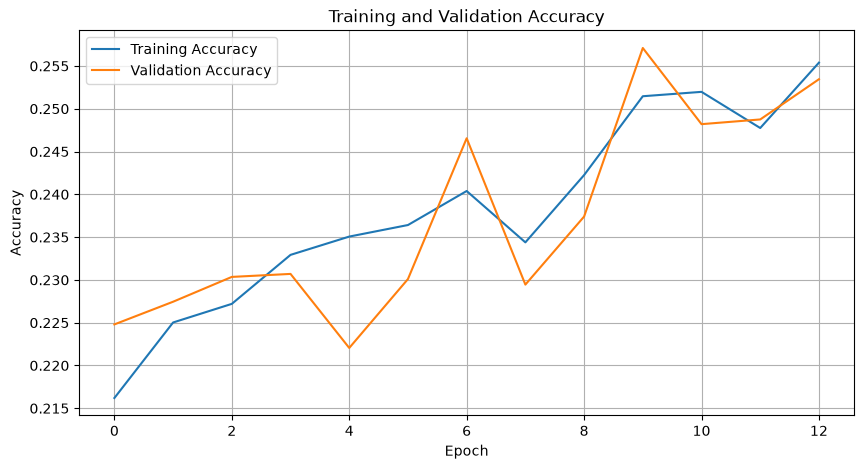

In [10]:
# plot training curves

import matplotlib.pyplot as plt

plt.figure(figsize = (10, 5))

plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

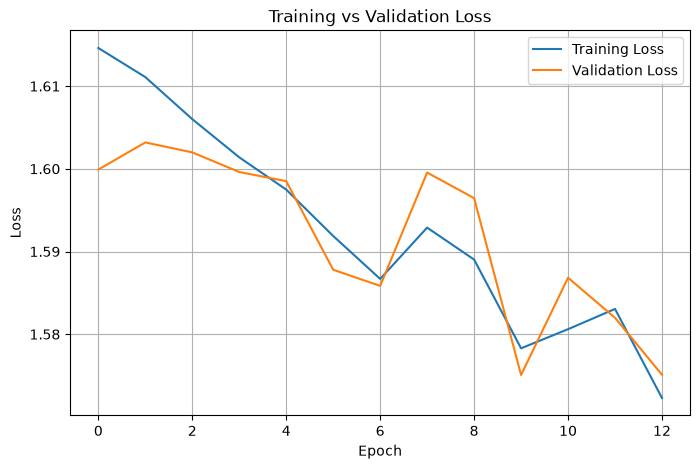

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Evaluation on test data

test_loss , test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose = 1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")


625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2593 - loss: 1.5762
Test Loss: 1.5762
Test accuracy : 0.2593


In [14]:
# Prediction

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis = 1)

625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step


In [15]:
# Performance metrics

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.21      0.30      4000
           1       0.32      0.04      0.07      4000
           2       0.24      0.17      0.20      4000
           3       0.27      0.10      0.14      4000
           4       0.23      0.78      0.36      4000

    accuracy                           0.26     20000
   macro avg       0.31      0.26      0.21     20000
weighted avg       0.31      0.26      0.21     20000



In [18]:
cm = confusion_matrix(y_test, y_pred)
cm 

array([[ 853,   89,  402,  129, 2527],
       [ 448,  145,  683,  269, 2455],
       [ 240,   94,  690,  389, 2587],
       [ 129,   77,  640,  390, 2764],
       [ 110,   45,  450,  287, 3108]])

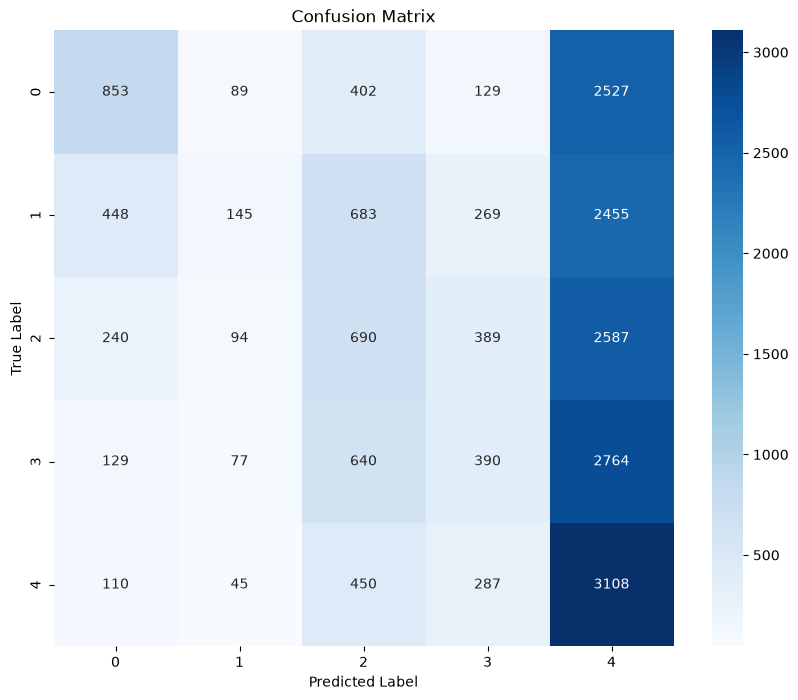

In [19]:
import seaborn as sns

plt.figure(figsize = (10, 8))

sns.heatmap(
    cm,
    annot= True,
    fmt= "d",
    cmap= "Blues",
    xticklabels= [0, 1, 2, 3, 4],
    yticklabels= [0, 1, 2, 3, 4]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [20]:
# Save the model

model.save("../models/rnn_model_v1.keras")